# Exploratory Data Analysis: Garbage Classification V2

Mini-project for Deep Learning course

## Goals of this notebook

1. Verify dataset integrity and structure
2. Analyze class distribution and identify imbalance
3. Inspect image properties (size, aspect ratio, color)
4. Visualize sample images from each class
5. Make data preprocessing decisions based on findings

## Dataset

Garbage Classification V2 by Suman Kunwar.
10 classes, ~12,000 labeled household waste images.
Reference: https://arxiv.org/pdf/2602.10500

In [5]:
import os
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plot style — clean and minimal
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

# Dataset constants
DATA_ROOT = Path('/kaggle/input/datasets/sumn2u/garbage-classification-v2/standardized_256')
NUM_CLASSES = 10
CLASS_NAMES = sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir()])

print(f"Data root: {DATA_ROOT}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Classes: {CLASS_NAMES}")

Data root: /kaggle/input/datasets/sumn2u/garbage-classification-v2/standardized_256
Number of classes: 10
Classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


## 1. Class distribution

We inspect how many images belong to each class. This will reveal
the level of class imbalance that we need to address in preprocessing.

In [6]:
class_counts = {}
for cls in CLASS_NAMES:
    cls_path = DATA_ROOT / cls
    n = len(list(cls_path.iterdir()))
    class_counts[cls] = n

df_counts = pd.DataFrame(
    {'class': list(class_counts.keys()),
     'count': list(class_counts.values())}
).sort_values('count', ascending=False).reset_index(drop=True)

df_counts['percentage'] = (df_counts['count'] / df_counts['count'].sum() * 100).round(2)

print(f"Total images: {df_counts['count'].sum():,}")
print(f"Min class: {df_counts['count'].min()} ({df_counts.iloc[-1]['class']})")
print(f"Max class: {df_counts['count'].max()} ({df_counts.iloc[0]['class']})")
print(f"Imbalance ratio (max/min): {df_counts['count'].max() / df_counts['count'].min():.2f}x")
print()
print(df_counts.to_string(index=False))

Total images: 12,259
Min class: 453 (trash)
Max class: 1892 (clothes)
Imbalance ratio (max/min): 4.18x

     class  count  percentage
   clothes   1892       15.43
     glass   1736       14.16
   plastic   1597       13.03
     shoes   1449       11.82
 cardboard   1411       11.51
     paper   1336       10.90
     metal    930        7.59
   battery    756        6.17
biological    699        5.70
     trash    453        3.70


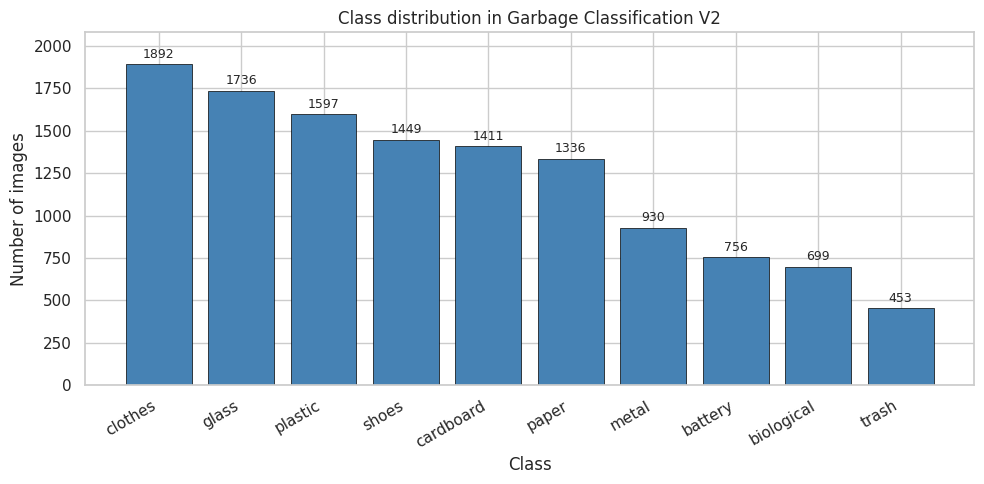

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(df_counts['class'], df_counts['count'],
              color='steelblue', edgecolor='black', linewidth=0.5)

# Add value labels on bars
for bar, count in zip(bars, df_counts['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(count), ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Class')
ax.set_ylabel('Number of images')
ax.set_title('Class distribution in Garbage Classification V2')
ax.set_ylim(0, df_counts['count'].max() * 1.1)

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

### Observations

- Total dataset size: 12,259 images, well within typical scale for transfer learning.
- Significant class imbalance: 4.18x ratio between the largest (clothes) and smallest (trash) class.
- The bottom three classes (metal, battery, biological, trash) account for less than 25% of the data combined.
- This imbalance will likely cause the baseline model to under-perform on minority classes.

### Implications for training

- Use stratified train/val/test split to maintain class proportions
- Apply class weights during training (inverse frequency)
- Track per-class metrics (precision/recall), not just overall accuracy
- Pay special attention to confusion matrix for minority classes

## 2. Image properties

Although images are nominally "standardized to 256x256", we verify this
empirically and check color channels.

In [8]:
def sample_image_properties(class_path, n_samples=30):
    """Sample n images from a class and return their properties."""
    files = list(class_path.iterdir())
    sampled = random.sample(files, min(n_samples, len(files)))
    
    props = []
    for f in sampled:
        try:
            img = Image.open(f)
            props.append({
                'class': class_path.name,
                'file': f.name,
                'width': img.width,
                'height': img.height,
                'mode': img.mode,
                'format': img.format,
            })
        except Exception as e:
            print(f"Error reading {f}: {e}")
    return props

# Sample 30 images per class
all_props = []
for cls in tqdm(CLASS_NAMES, desc="Sampling images"):
    all_props.extend(sample_image_properties(DATA_ROOT / cls, n_samples=30))

df_props = pd.DataFrame(all_props)
print(f"Sampled {len(df_props)} images total")
print(f"\nWidth stats:\n{df_props['width'].describe()}")
print(f"\nHeight stats:\n{df_props['height'].describe()}")
print(f"\nUnique image modes: {df_props['mode'].unique()}")
print(f"Unique formats: {df_props['format'].unique()}")

Sampling images:   0%|          | 0/10 [00:00<?, ?it/s]

Sampled 300 images total

Width stats:
count    300.0
mean     256.0
std        0.0
min      256.0
25%      256.0
50%      256.0
75%      256.0
max      256.0
Name: width, dtype: float64

Height stats:
count    300.0
mean     256.0
std        0.0
min      256.0
25%      256.0
50%      256.0
75%      256.0
max      256.0
Name: height, dtype: float64

Unique image modes: ['RGB']
Unique formats: ['JPEG']


## 3. Sample images from each class

Visual inspection helps catch labeling errors, unusual examples,
and dataset diversity issues.

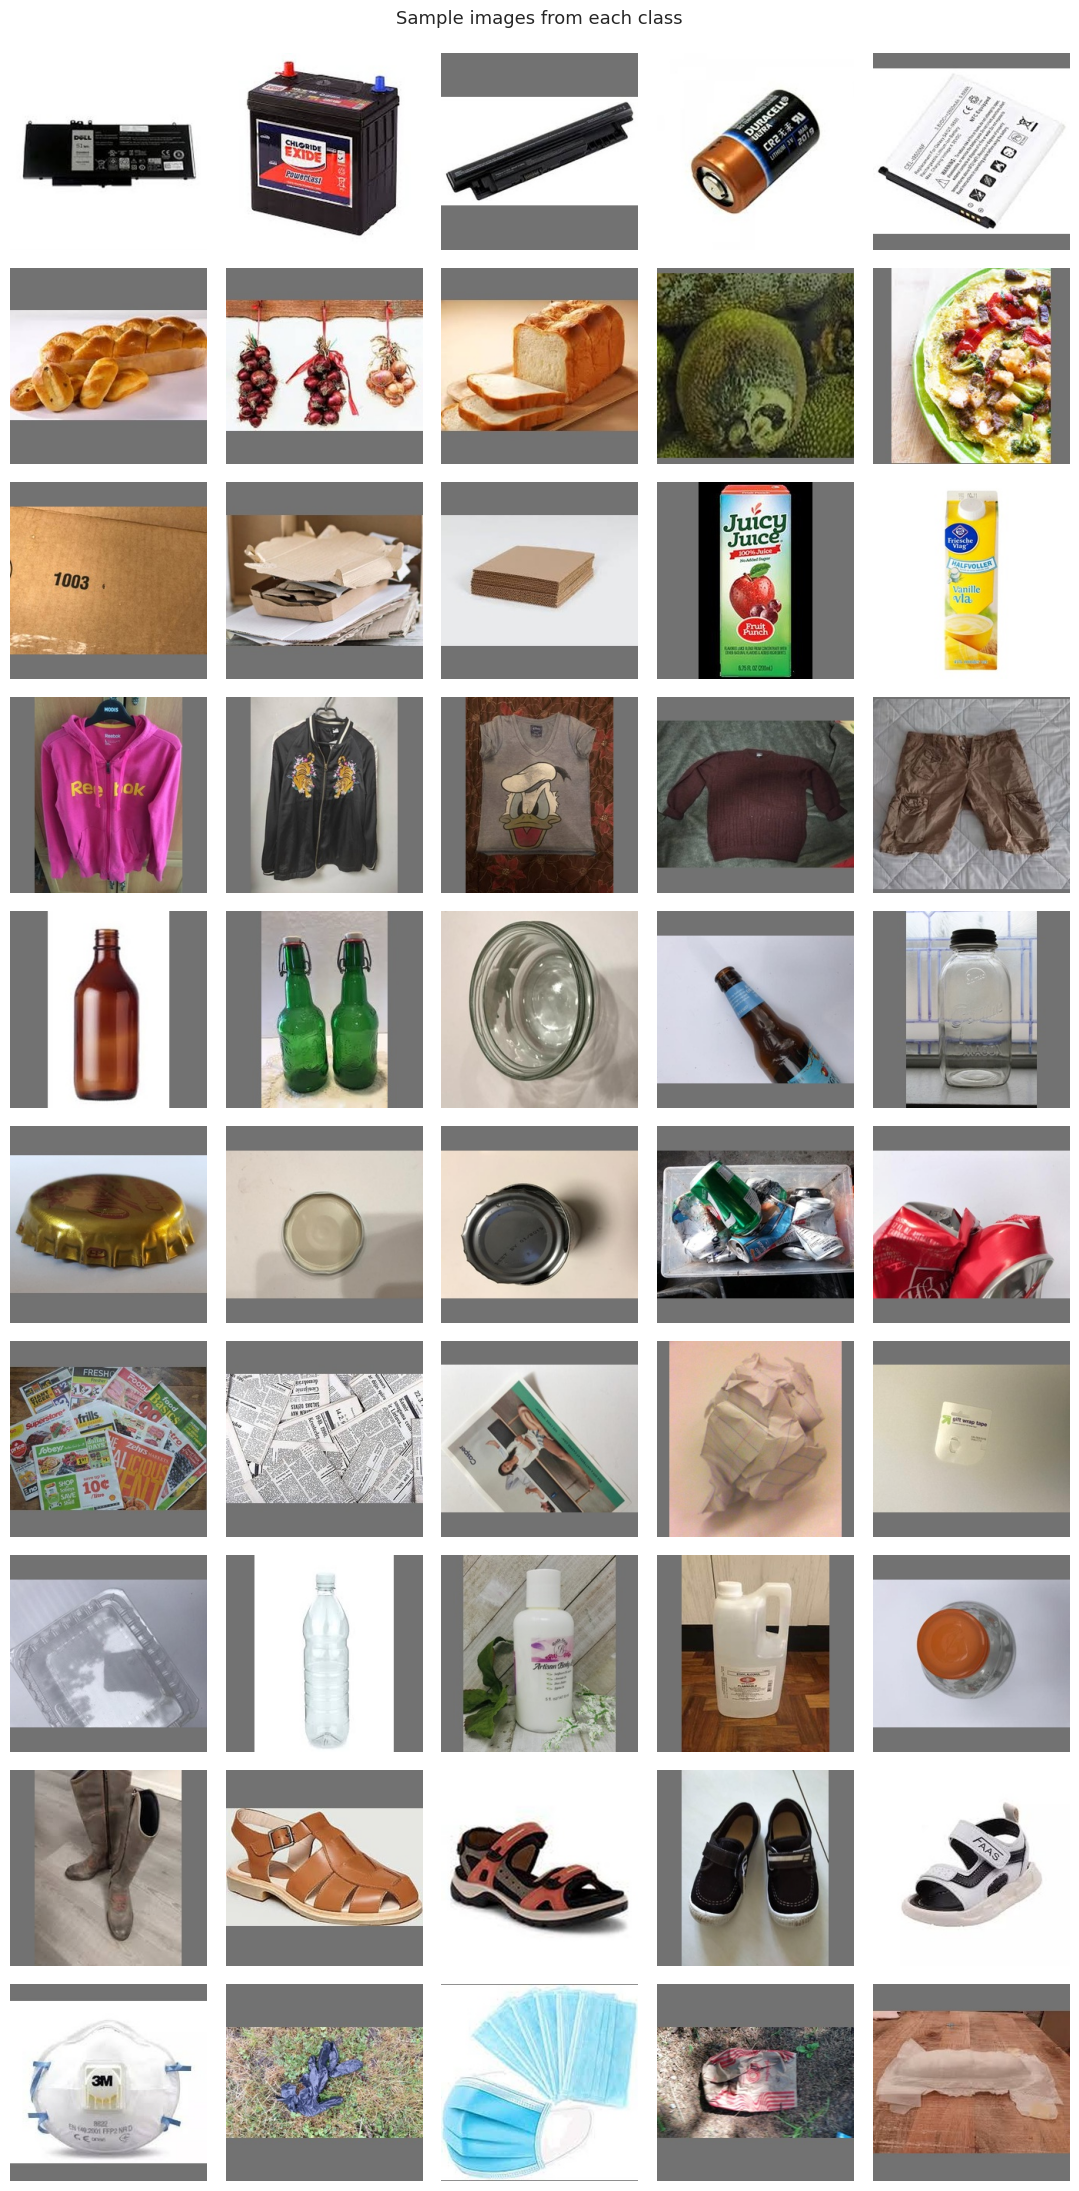

In [9]:
def show_samples_per_class(data_root, class_names, n_per_class=5, seed=42):
    """Display n random samples from each class."""
    random.seed(seed)
    n_classes = len(class_names)
    
    fig, axes = plt.subplots(n_classes, n_per_class,
                             figsize=(n_per_class * 2.2, n_classes * 2.2))
    
    for row, cls in enumerate(class_names):
        cls_path = data_root / cls
        files = random.sample(list(cls_path.iterdir()), n_per_class)
        
        for col, f in enumerate(files):
            img = Image.open(f)
            axes[row, col].imshow(img)
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].set_ylabel(cls, rotation=0, ha='right',
                                          va='center', fontsize=11,
                                          labelpad=40)
    
    plt.suptitle('Sample images from each class', fontsize=13, y=0.995)
    plt.tight_layout()
    plt.savefig('class_samples.png', bbox_inches='tight')
    plt.show()

show_samples_per_class(DATA_ROOT, CLASS_NAMES, n_per_class=5)

## 4. Color distribution analysis

We check whether classes have characteristic color profiles that might
help (or hurt) classification.

Computing avg colors:   0%|          | 0/10 [00:00<?, ?it/s]

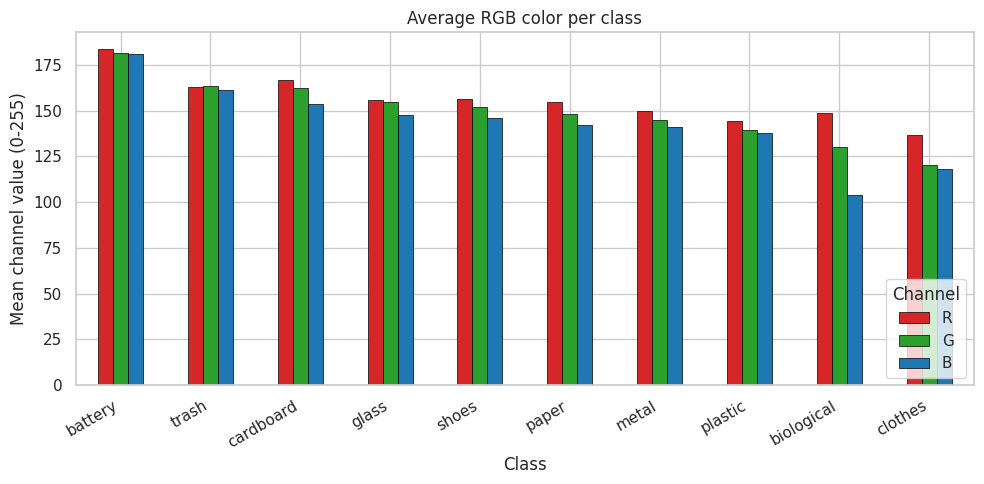

                R      G      B  brightness
battery     183.7  181.8  180.8       182.1
trash       163.2  163.3  161.1       162.5
cardboard   166.9  162.6  153.7       161.0
glass       155.8  154.7  147.8       152.8
shoes       156.6  151.9  146.2       151.6
paper       154.8  148.2  142.1       148.4
metal       150.0  145.2  140.9       145.4
plastic     144.6  139.7  137.6       140.6
biological  148.6  130.1  103.8       127.5
clothes     136.9  120.4  118.1       125.1


In [10]:
def average_color(img):
    """Return mean RGB of an image."""
    arr = np.array(img.convert('RGB'))
    return arr.reshape(-1, 3).mean(axis=0)

# Sample 50 images per class to compute average color
class_colors = {}
for cls in tqdm(CLASS_NAMES, desc="Computing avg colors"):
    files = random.sample(list((DATA_ROOT / cls).iterdir()), 50)
    colors = np.array([average_color(Image.open(f)) for f in files])
    class_colors[cls] = colors.mean(axis=0)

# Build bar chart
df_colors = pd.DataFrame(class_colors, index=['R', 'G', 'B']).T
df_colors['brightness'] = df_colors.mean(axis=1)
df_colors = df_colors.sort_values('brightness', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
df_colors[['R', 'G', 'B']].plot(kind='bar', ax=ax,
                                  color=['#d62728', '#2ca02c', '#1f77b4'],
                                  edgecolor='black', linewidth=0.5)
ax.set_xlabel('Class')
ax.set_ylabel('Mean channel value (0-255)')
ax.set_title('Average RGB color per class')
ax.legend(title='Channel', loc='lower right')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('class_colors.png', bbox_inches='tight')
plt.show()

print(df_colors.round(1))

## Summary and decisions for training

### Dataset profile
- 12,259 images, 10 classes, 256x256 RGB JPEG
- Class imbalance ratio 4.18x (trash: 453, clothes: 1892)
- Images are visually diverse, no obvious labeling errors found in samples

### Preprocessing decisions
- Train/Validation/Test split: 70 / 15 / 15, stratified by class
- Random crop to 224x224 during training (compatible with ResNet50, EfficientNet)
- Center crop to 224x224 during validation and test
- Normalization: use ImageNet means/stds for transfer learning models
- Augmentations: horizontal flip, random rotation up to 15 degrees, mild brightness/contrast jitter

### Handling imbalance
- Compute class weights as inverse frequency
- Report per-class precision, recall, F1
- Use macro-averaged F1 as the main metric alongside accuracy

### Next steps
- Implement data pipeline in src/data.py
- Build baseline CNN
- Establish reference accuracy